# Titanic - Machine Learning from Disaster
## model_experiment.ipynb

In [29]:
!pip install mlflow category_encoders dagshub scikit-learn --quiet


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [31]:
import os
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

import category_encoders as ce
import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## MLflow / DagsHub Setup

In [32]:
USE_DAGSHUB = True

DAGSHUB_USERNAME = "konstantine25b"
DAGSHUB_REPO     = "titanic-for-tutoring"
DAGSHUB_TOKEN    = "2eaae1414498f697a730998443323fc67f26b842"

if USE_DAGSHUB:
    os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
    os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN
    tracking_uri = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"
    mlflow.set_tracking_uri(tracking_uri)
else:
    mlflow.set_tracking_uri("mlruns")

EXPERIMENT_NAME = "titanic-experiments"
mlflow.set_experiment(EXPERIMENT_NAME)
print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow


## Data Loading

In [33]:
train_raw = pd.read_csv("data/train_data.csv", index_col=0)
test_raw  = pd.read_csv("data/test_data.csv",  index_col=0)

print("Train shape:", train_raw.shape)
print("Test shape: ", test_raw.shape)
train_raw.head()

Train shape: (792, 16)
Test shape:  (100, 16)


,PassengerId,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
0,1,0,1,0.2750,0.014151,0,0,1,0.1,1,0,0,0,0,0,1
1,2,1,0,0.4750,0.139136,1,0,0,0.1,1,0,0,0,1,0,0
2,3,1,0,0.3250,0.015469,0,0,1,0.0,0,0,0,1,0,0,1
3,4,1,0,0.4375,0.103644,1,0,0,0.1,1,0,0,0,0,0,1
4,5,0,1,0.4375,0.015713,0,0,1,0.0,1,0,0,0,0,0,1


In [34]:
print("Columns:", train_raw.columns.tolist())
print("\nMissing values:")
print(train_raw.isnull().sum())

Columns: ['PassengerId', 'Survived', 'Sex', 'Age', 'Fare', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Family_size', 'Title_1', 'Title_2', 'Title_3', 'Title_4', 'Emb_1', 'Emb_2', 'Emb_3']

Missing values:
PassengerId    0
Survived       0
Sex            0
Age            0
Fare           0
Pclass_1       0
Pclass_2       0
Pclass_3       0
Family_size    0
Title_1        0
Title_2        0
Title_3        0
Title_4        0
Emb_1          0
Emb_2          0
Emb_3          0
dtype: int64


## Train / Validation Split

Split before encoding so all encoders (WOE, OHE) are fit only on training data.

In [35]:
TARGET      = 'Survived'
VAL_SIZE    = 0.2
RANDOM_SEED = 42

train_split, val_split = train_test_split(
    train_raw,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=train_raw[TARGET]
)

train_split = train_split.reset_index(drop=True)
val_split   = val_split.reset_index(drop=True)

print(f"Train split: {train_split.shape}  |  Val split: {val_split.shape}")
print(f"Survival rate — train: {train_split[TARGET].mean():.3f}  val: {val_split[TARGET].mean():.3f}")

Train split: (633, 16)  |  Val split: (159, 16)
Survival rate — train: 0.387  val: 0.384


---
# Data Cleaning

The dataset is already pre-processed (normalized Age/Fare, OHE-encoded Pclass/Title/Embarked).  
Cleaning step: drop PassengerId, check for nulls, remove duplicates, verify dtypes.

In [36]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.drop(columns=['PassengerId'], errors='ignore', inplace=True)
    df.drop_duplicates(inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True)
    return df.reset_index(drop=True)


train_clean = clean(train_split)
val_clean   = clean(val_split)
test_clean  = clean(test_raw)

print("After cleaning — train:", train_clean.shape, "  val:", val_clean.shape)
print("Remaining nulls:")
print(train_clean.isnull().sum())
train_clean.head()

After cleaning — train: (571, 15)   val: (148, 15)
Remaining nulls:
Survived       0
Sex            0
Age            0
Fare           0
Pclass_1       0
Pclass_2       0
Pclass_3       0
Family_size    0
Title_1        0
Title_2        0
Title_3        0
Title_4        0
Emb_1          0
Emb_2          0
Emb_3          0
dtype: int64


,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
0,1,0,0.3750,0.168837,1,0,0,0.0,0,0,0,1,0,0,1
1,0,1,0.4250,0.040989,0,1,0,0.1,1,0,0,0,0,0,1
2,0,0,0.6250,0.056043,1,0,0,0.0,0,0,0,1,1,0,0
3,1,0,0.3000,0.028302,0,1,0,0.2,1,0,0,0,0,0,1
4,0,1,0.2375,0.103644,1,0,0,0.1,1,0,0,0,0,0,1


---
# Feature Engineering

The dataset carries OHE columns (Pclass_1/2/3, Title_1-4, Emb_1-3).  
We reconstruct the original categorical labels so we can apply OHE and WOE from scratch.  
Additional features: `IsAlone` from `Family_size`, and quantile bins for Age and Fare.

In [37]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['Pclass']   = (df[['Pclass_1','Pclass_2','Pclass_3']]
                      .idxmax(axis=1)
                      .str.replace('Pclass_', '', regex=False)
                      .astype(int))

    df['Title']    = (df[['Title_1','Title_2','Title_3','Title_4']]
                      .idxmax(axis=1)
                      .str.replace('Title_', '', regex=False)
                      .astype(int))

    df['Embarked'] = (df[['Emb_1','Emb_2','Emb_3']]
                      .idxmax(axis=1)
                      .str.replace('Emb_', '', regex=False)
                      .astype(int))

    df['IsAlone']  = (df['Family_size'] == 0).astype(int)

    df.drop(columns=['Pclass_1','Pclass_2','Pclass_3',
                     'Title_1','Title_2','Title_3','Title_4',
                     'Emb_1','Emb_2','Emb_3'], inplace=True)

    return df


train_fe = add_features(train_clean)
val_fe   = add_features(val_clean)
test_fe  = add_features(test_clean)

print("Features after engineering:", train_fe.columns.tolist())
train_fe.head()

Features after engineering: ['Survived', 'Sex', 'Age', 'Fare', 'Family_size', 'Pclass', 'Title', 'Embarked', 'IsAlone']


,Survived,Sex,Age,Fare,Family_size,Pclass,Title,Embarked,IsAlone
0,1,0,0.3750,0.168837,0.0,1,4,3,1
1,0,1,0.4250,0.040989,0.1,2,1,3,0
2,0,0,0.6250,0.056043,0.0,1,4,1,1
3,1,0,0.3000,0.028302,0.2,2,1,3,0
4,0,1,0.2375,0.103644,0.1,1,1,3,0


## One-Hot Encoding (OHE)

Categories learned from **train only**. Val and test aligned via `reindex`.

In [38]:
TARGET       = 'Survived'
CAT_COLS     = ['Sex', 'Pclass', 'Title', 'Embarked']
NUMERIC_COLS = ['Age', 'Fare', 'Family_size', 'IsAlone']


def apply_ohe(train_df: pd.DataFrame, other_dfs: list, cols: list):
    train_dummies = pd.get_dummies(train_df[cols].astype(str), columns=cols, drop_first=False)
    ohe_columns   = train_dummies.columns.tolist()
    results       = [train_dummies.reset_index(drop=True)]
    for df in other_dfs:
        dummies = pd.get_dummies(df[cols].astype(str), columns=cols, drop_first=False)
        results.append(dummies.reindex(columns=ohe_columns, fill_value=0).reset_index(drop=True))
    return results


y_train = train_fe[TARGET].reset_index(drop=True)
y_val   = val_fe[TARGET].reset_index(drop=True)

ohe_parts = apply_ohe(train_fe, [val_fe, test_fe], CAT_COLS)
ohe_tr, ohe_vl, ohe_te = ohe_parts

X_ohe_train = pd.concat([train_fe[NUMERIC_COLS].reset_index(drop=True), ohe_tr], axis=1)
X_ohe_val   = pd.concat([val_fe[NUMERIC_COLS].reset_index(drop=True),   ohe_vl], axis=1)
X_ohe_test  = pd.concat([test_fe[NUMERIC_COLS].reset_index(drop=True),  ohe_te], axis=1)

print('OHE train shape:', X_ohe_train.shape, ' val:', X_ohe_val.shape)
X_ohe_train.head()

OHE train shape: (571, 16)  val: (148, 16)


,Age,Fare,Family_size,IsAlone,Sex_0,Sex_1,Pclass_1,Pclass_2,Pclass_3,Title_1,Title_2,Title_3,Title_4,Embarked_1,Embarked_2,Embarked_3
0,0.3750,0.168837,0.0,1,True,False,True,False,False,False,False,False,True,False,False,True
1,0.4250,0.040989,0.1,0,False,True,False,True,False,True,False,False,False,False,False,True
2,0.6250,0.056043,0.0,1,True,False,True,False,False,False,False,False,True,True,False,False
3,0.3000,0.028302,0.2,0,True,False,False,True,False,True,False,False,False,False,False,True
4,0.2375,0.103644,0.1,0,False,True,True,False,False,True,False,False,False,False,False,True


## Weight of Evidence (WOE) Encoding

Encoder fit on **train only**, then applied to val and test.  
WOE = ln(P(X|Y=1) / P(X|Y=0)) — natural for binary classification.

In [39]:
WOE_COLS = ['Sex', 'Pclass', 'Title', 'Embarked']

woe_encoder = ce.WOEEncoder(cols=WOE_COLS, regularization=1.0)


def prep_woe(df: pd.DataFrame) -> pd.DataFrame:
    return df[NUMERIC_COLS + WOE_COLS].copy().reset_index(drop=True)


woe_encoder.fit(prep_woe(train_fe), y_train)

X_woe_train = woe_encoder.transform(prep_woe(train_fe))
X_woe_val   = woe_encoder.transform(prep_woe(val_fe))
X_woe_test  = woe_encoder.transform(prep_woe(test_fe))

print('WOE train shape:', X_woe_train.shape, ' val:', X_woe_val.shape)
X_woe_train.head()

WOE train shape: (571, 8)  val: (148, 8)


,Age,Fare,Family_size,IsAlone,Sex,Pclass,Title,Embarked
0,0.3750,0.168837,0.0,1,1.461780,0.845700,1.303669,-0.146548
1,0.4250,0.040989,0.1,0,-0.982567,0.384864,-0.412340,-0.146548
2,0.6250,0.056043,0.0,1,1.461780,0.845700,1.303669,0.561251
3,0.3000,0.028302,0.2,0,1.461780,0.384864,-0.412340,-0.146548
4,0.2375,0.103644,0.1,0,-0.982567,0.845700,-0.412340,-0.146548


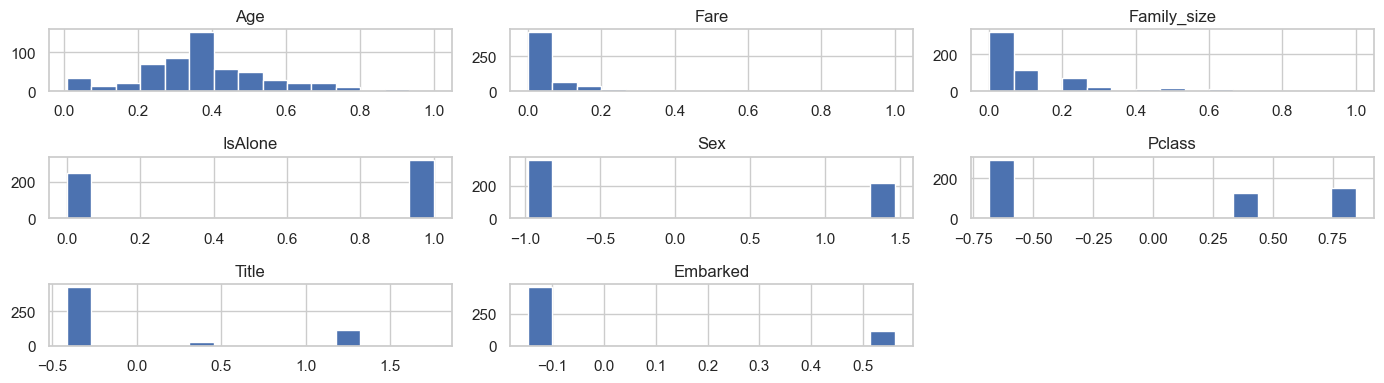

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
X_ohe_train.iloc[:, :10].hist(ax=axes[0], bins=15)
axes[0].set_title('OHE Feature Distributions (train, first 10 cols)')
X_woe_train.hist(ax=axes[1], bins=15)
axes[1].set_title('WOE Feature Distributions (train)')
plt.tight_layout()
plt.show()

---
# Feature Selection
## Recursive Feature Elimination (RFE)

Fit on **train split only**.


[OHE] Selected 15 features:
['Age', 'Fare', 'Family_size', 'IsAlone', 'Sex_0', 'Sex_1', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Title_1', 'Title_3', 'Title_4', 'Embarked_1', 'Embarked_2', 'Embarked_3']


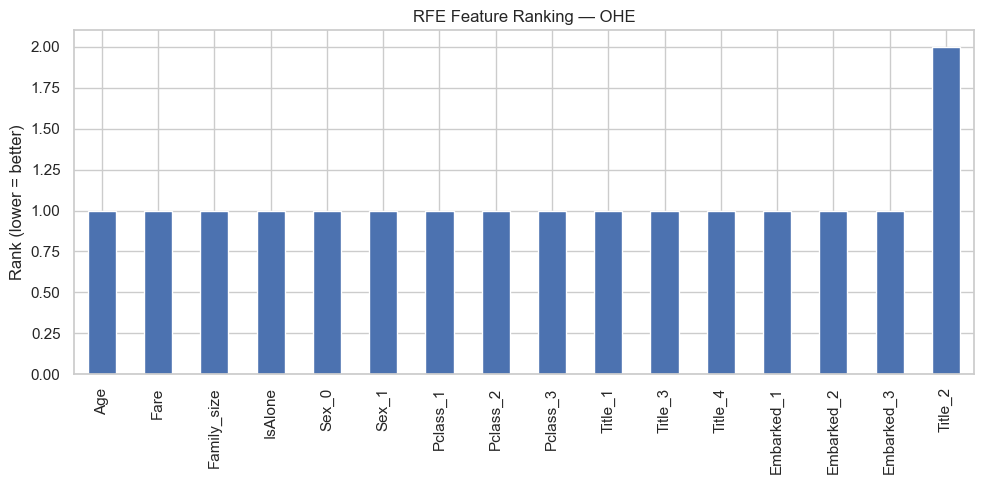


[WOE] Selected 8 features:
['Age', 'Fare', 'Family_size', 'IsAlone', 'Sex', 'Pclass', 'Title', 'Embarked']


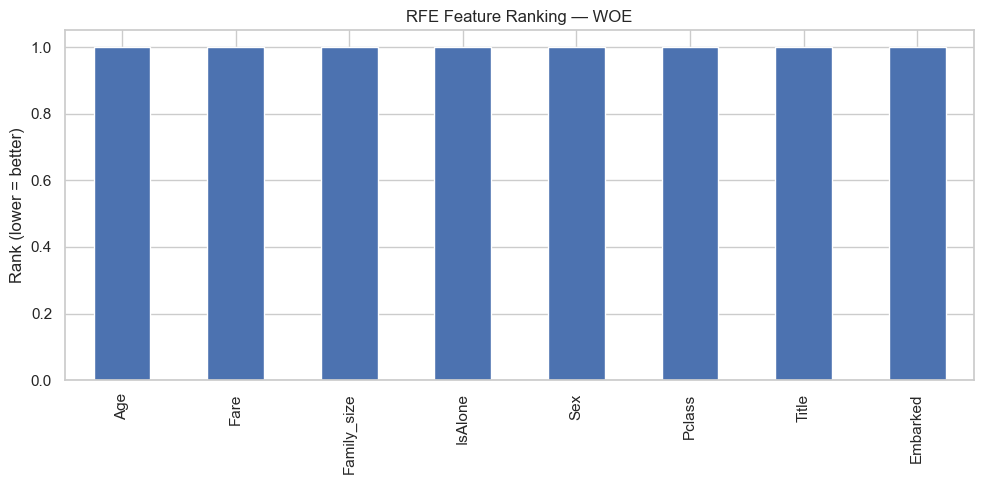

In [41]:
def run_rfe(X_tr: pd.DataFrame, y_tr: pd.Series, n_features: int, label: str):
    estimator = RandomForestClassifier(n_estimators=100, random_state=42)
    scaler    = StandardScaler()
    X_scaled  = scaler.fit_transform(X_tr.values.astype(float))
    rfe       = RFE(estimator=estimator, n_features_to_select=n_features, step=1)
    rfe.fit(X_scaled, y_tr)
    selected  = X_tr.columns[rfe.support_].tolist()
    ranking   = pd.Series(rfe.ranking_, index=X_tr.columns).sort_values()

    print(f"\n[{label}] Selected {n_features} features:")
    print(selected)

    plt.figure(figsize=(10, 5))
    ranking.head(n_features + 5).plot(kind='bar')
    plt.title(f'RFE Feature Ranking — {label}')
    plt.ylabel('Rank (lower = better)')
    plt.tight_layout()
    plt.show()

    return selected


N_FEATURES_OHE = min(15, X_ohe_train.shape[1])
N_FEATURES_WOE = min(8,  X_woe_train.shape[1])

selected_ohe = run_rfe(X_ohe_train, y_train, N_FEATURES_OHE, 'OHE')
selected_woe = run_rfe(X_woe_train, y_train, N_FEATURES_WOE, 'WOE')

In [42]:
X_ohe_tr_sel   = X_ohe_train[selected_ohe]
X_ohe_val_sel  = X_ohe_val[selected_ohe]
X_ohe_test_sel = X_ohe_test[selected_ohe]

X_woe_tr_sel   = X_woe_train[selected_woe]
X_woe_val_sel  = X_woe_val[selected_woe]
X_woe_test_sel = X_woe_test[selected_woe]

print("OHE — train:", X_ohe_tr_sel.shape, " val:", X_ohe_val_sel.shape)
print("WOE — train:", X_woe_tr_sel.shape, " val:", X_woe_val_sel.shape)

OHE — train: (571, 15)  val: (148, 15)
WOE — train: (571, 8)  val: (148, 8)


---
# Training

Each run logs: params, CV metrics (train split), val metrics (held-out val), confusion matrix, ROC curve, feature importance.

In [44]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def log_run(
    run_name: str,
    model,
    X_tr: pd.DataFrame,
    y_tr: pd.Series,
    X_vl: pd.DataFrame,
    y_vl: pd.Series,
    encoding: str,
    extra_params: dict = None,
    register: bool = False,
):
    X_tr_arr = X_tr.values.astype(float)
    X_vl_arr = X_vl.values.astype(float)

    acc_scores = cross_val_score(model, X_tr_arr, y_tr, cv=CV, scoring='accuracy')
    auc_scores = cross_val_score(model, X_tr_arr, y_tr, cv=CV, scoring='roc_auc')
    f1_scores  = cross_val_score(model, X_tr_arr, y_tr, cv=CV, scoring='f1')

    model.fit(X_tr_arr, y_tr)
    y_pred = model.predict(X_vl_arr)
    y_prob = model.predict_proba(X_vl_arr)[:, 1] if hasattr(model, 'predict_proba') else None

    val_auc = roc_auc_score(y_vl, y_prob) if y_prob is not None else 0.0

    with mlflow.start_run(run_name=run_name):
        params = {
            'model':      type(model).__name__,
            'encoding':   encoding,
            'n_features': X_tr.shape[1],
            'val_size':   len(y_vl),
        }
        if extra_params:
            params.update(extra_params)
        mlflow.log_params(params)

        mlflow.log_metrics({
            'cv_acc_mean':  acc_scores.mean(),
            'cv_acc_std':   acc_scores.std(),
            'cv_auc_mean':  auc_scores.mean(),
            'cv_auc_std':   auc_scores.std(),
            'cv_f1_mean':   f1_scores.mean(),
            'cv_f1_std':    f1_scores.std(),
            'val_accuracy': accuracy_score(y_vl, y_pred),
            'val_f1':       f1_score(y_vl, y_pred),
            'val_auc':      val_auc,
        })

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        ConfusionMatrixDisplay(confusion_matrix(y_vl, y_pred)).plot(ax=axes[0], colorbar=False)
        axes[0].set_title('Confusion Matrix (val)')
        if y_prob is not None:
            RocCurveDisplay.from_predictions(y_vl, y_prob, ax=axes[1])
            axes[1].set_title('ROC Curve (val)')
        plt.suptitle(run_name)
        plt.tight_layout()
        plt.show()

        if hasattr(model, 'feature_importances_'):
            imp = pd.Series(model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
            fig2, ax2 = plt.subplots(figsize=(10, 4))
            imp.head(15).plot(kind='bar', ax=ax2)
            ax2.set_title(f'Feature Importance — {run_name}')
            plt.tight_layout()
            plt.show()

        if register:
            mlflow.sklearn.log_model(
                model, artifact_path='model',
                registered_model_name='titanic-best-model'
            )
        else:
            mlflow.sklearn.log_model(model, artifact_path='model')

        run_id = mlflow.active_run().info.run_id

    print(f"[{run_name}] cv_auc={auc_scores.mean():.4f} val_auc={val_auc:.4f}  run_id={run_id}")
    return {
        'run_name': run_name,
        'run_id':   run_id,
        'cv_acc':   acc_scores.mean(),
        'cv_auc':   auc_scores.mean(),
        'cv_f1':    f1_scores.mean(),
        'val_auc':  val_auc,
        'val_acc':  accuracy_score(y_vl, y_pred),
    }

### Logistic Regression — OHE vs WOE

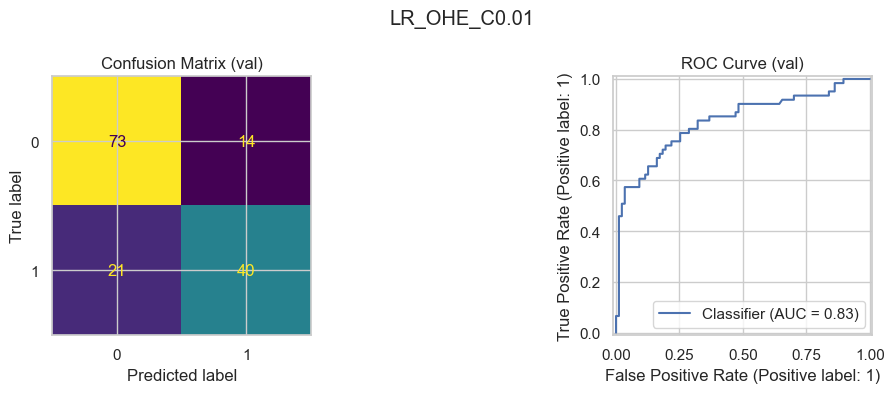

2026/03/28 14:31:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:31:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR_OHE_C0.01 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/ae074f8cfb9b461e89eac0c31ced3726
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[LR_OHE_C0.01] cv_auc=0.8495 val_auc=0.8331  run_id=ae074f8cfb9b461e89eac0c31ced3726


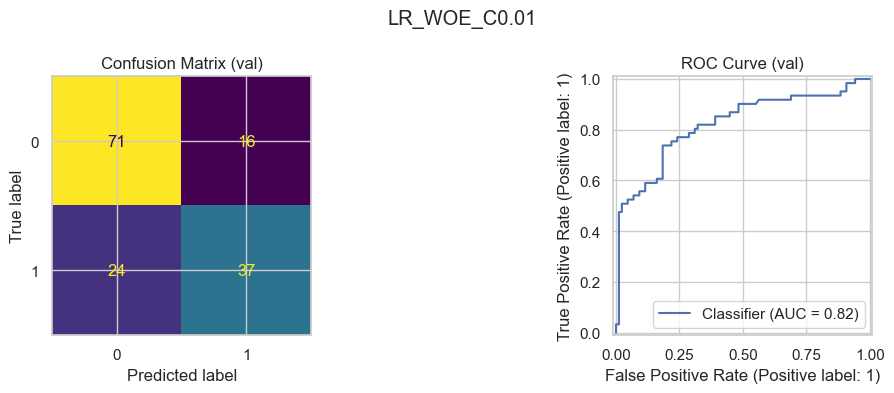

2026/03/28 14:31:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:31:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR_WOE_C0.01 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/bc182fa947ee4770849fd4dbebe87934
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[LR_WOE_C0.01] cv_auc=0.8383 val_auc=0.8215  run_id=bc182fa947ee4770849fd4dbebe87934


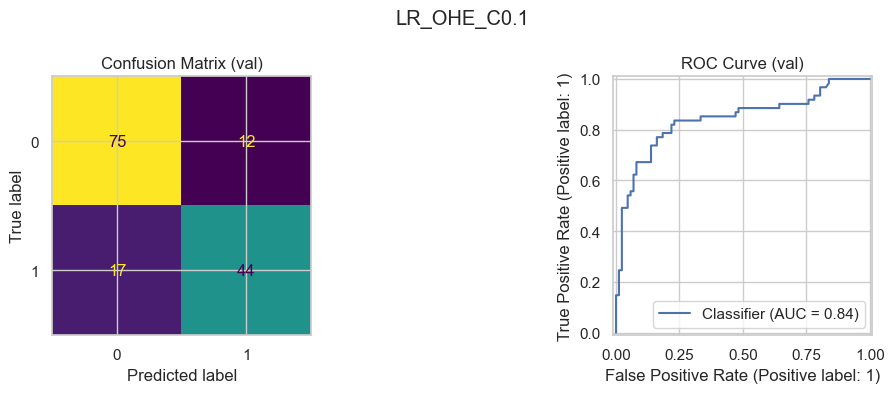

2026/03/28 14:31:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:32:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR_OHE_C0.1 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/9b35dae0566448ec90ce23b9a773709d
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[LR_OHE_C0.1] cv_auc=0.8581 val_auc=0.8426  run_id=9b35dae0566448ec90ce23b9a773709d


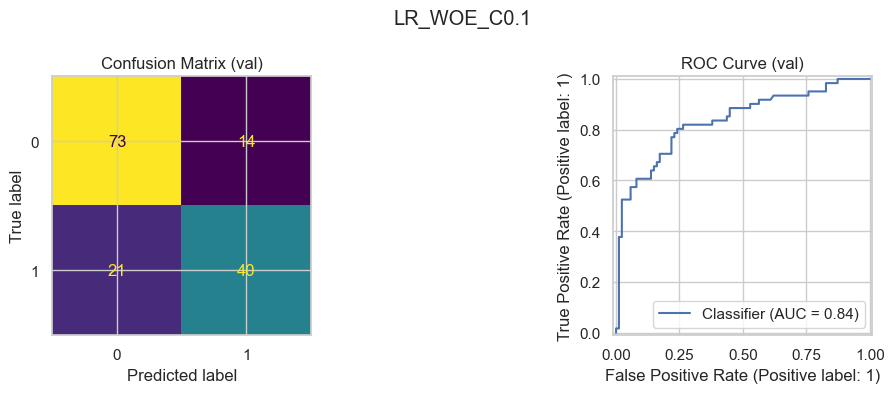

2026/03/28 14:32:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:32:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR_WOE_C0.1 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/687fa22d5c0a419b92ce6a02803f3ec8
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[LR_WOE_C0.1] cv_auc=0.8464 val_auc=0.8354  run_id=687fa22d5c0a419b92ce6a02803f3ec8


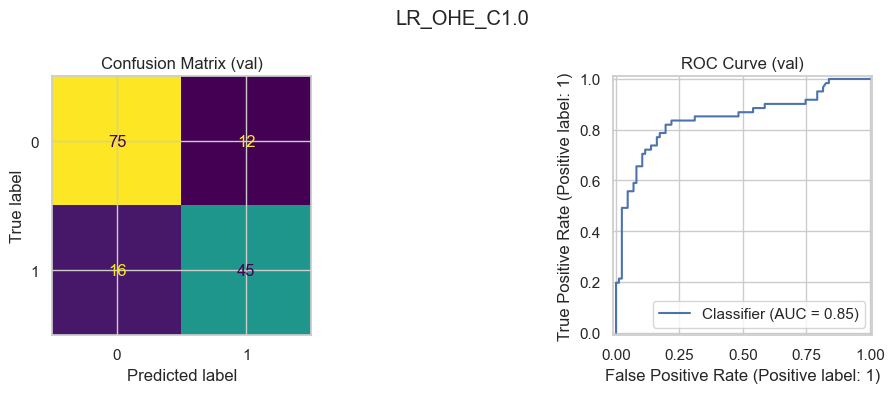

2026/03/28 14:32:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:32:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR_OHE_C1.0 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/d3f7996149fc4da9a17094c6ba0e6bcb
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[LR_OHE_C1.0] cv_auc=0.8575 val_auc=0.8452  run_id=d3f7996149fc4da9a17094c6ba0e6bcb


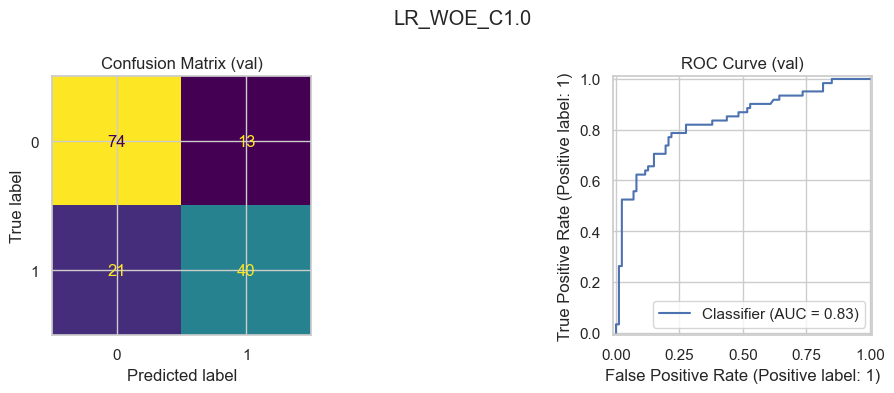

2026/03/28 14:33:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:33:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR_WOE_C1.0 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/d219513576bf4e249792b189c42393b7
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[LR_WOE_C1.0] cv_auc=0.8441 val_auc=0.8348  run_id=d219513576bf4e249792b189c42393b7


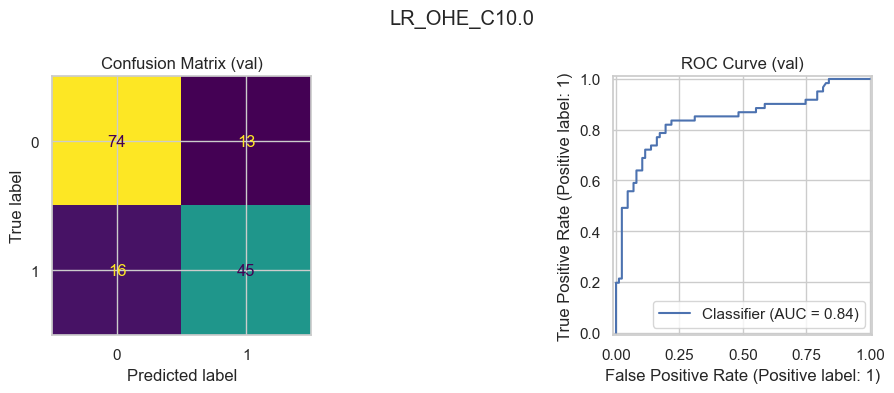

2026/03/28 14:33:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:33:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR_OHE_C10.0 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/2ea28f36ab5a4291a0552ef9bb247e97
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[LR_OHE_C10.0] cv_auc=0.8574 val_auc=0.8445  run_id=2ea28f36ab5a4291a0552ef9bb247e97


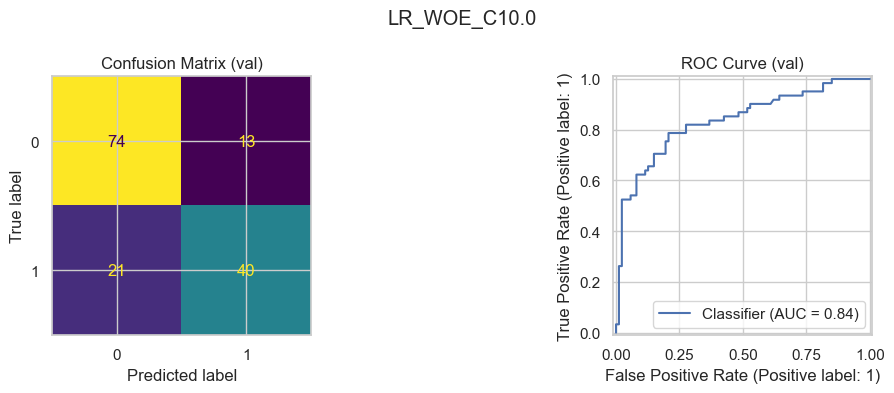

2026/03/28 14:34:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:34:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR_WOE_C10.0 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/2c22f310ebea4544846e6a6fdd16acda
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[LR_WOE_C10.0] cv_auc=0.8443 val_auc=0.8356  run_id=2c22f310ebea4544846e6a6fdd16acda


In [ ]:
results = []

for C in [ 0.1, 1.0]:
    lr = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=C, max_iter=1000, random_state=42))
    ])
    results.append(log_run(
        f'LR_OHE_C{C}', lr,
        X_ohe_tr_sel, y_train, X_ohe_val_sel, y_val,
        'OHE', extra_params={'C': C}
    ))
    results.append(log_run(
        f'LR_WOE_C{C}', lr,
        X_woe_tr_sel, y_train, X_woe_val_sel, y_val,
        'WOE', extra_params={'C': C}
    ))

### Random Forest — OHE vs WOE

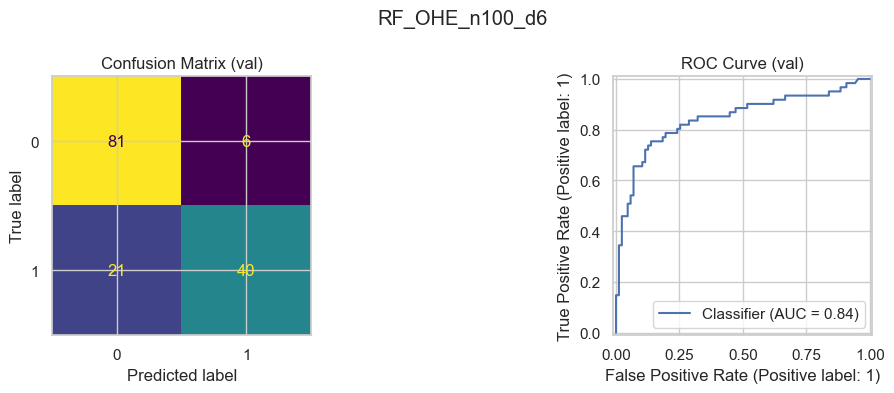

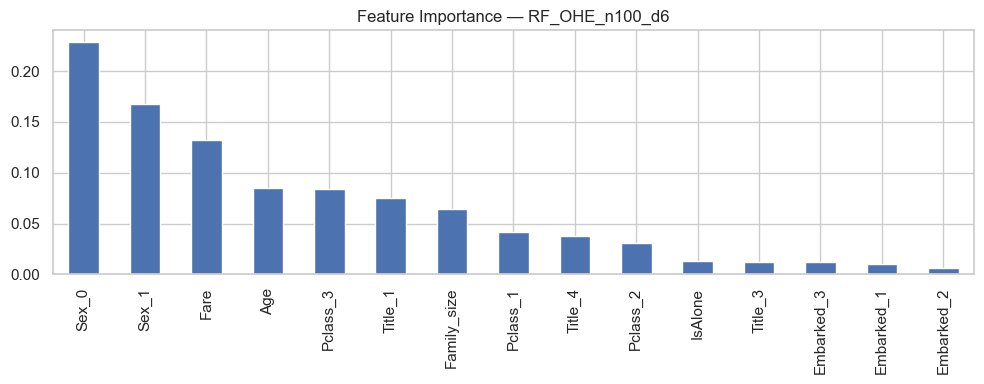

2026/03/28 14:35:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:35:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RF_OHE_n100_d6 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/56e129fbf96e4d45a6e665f3a3179967
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[RF_OHE_n100_d6] cv_auc=0.8529 val_auc=0.8437  run_id=56e129fbf96e4d45a6e665f3a3179967


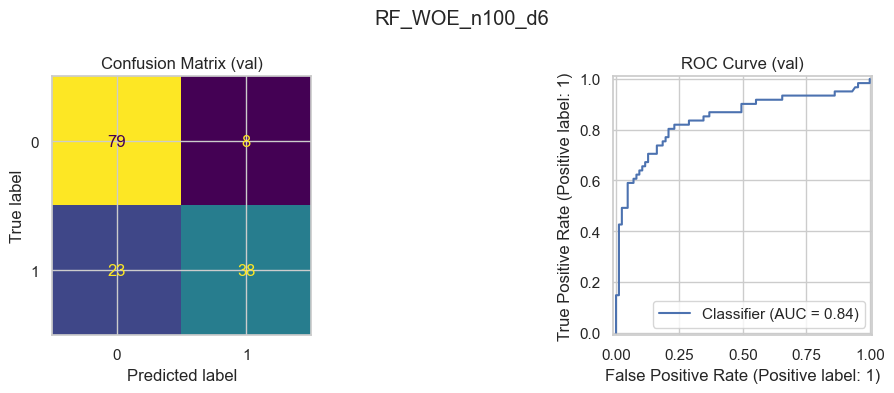

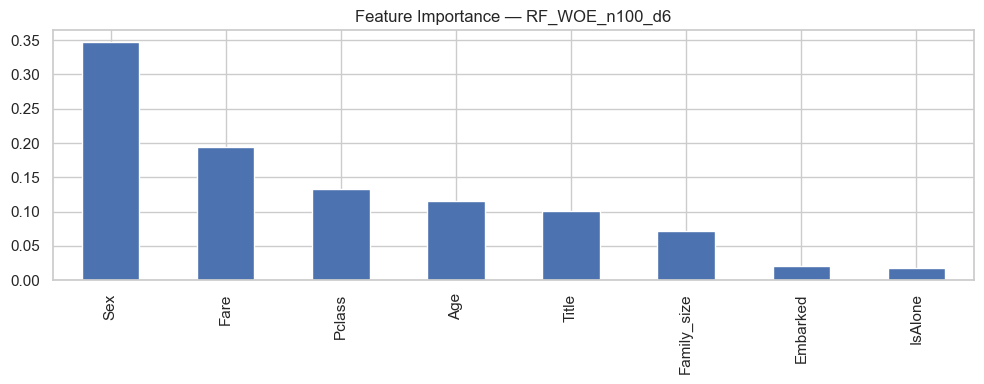

2026/03/28 14:35:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:35:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RF_WOE_n100_d6 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/1c28211be1a74f5aa607a3e022f5cc76
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[RF_WOE_n100_d6] cv_auc=0.8549 val_auc=0.8431  run_id=1c28211be1a74f5aa607a3e022f5cc76


In [46]:
for n_est in [100]:
    for max_depth in [6]:
        rf = RandomForestClassifier(
            n_estimators=n_est, max_depth=max_depth,
            min_samples_leaf=2, random_state=42
        )
        results.append(log_run(
            f'RF_OHE_n{n_est}_d{max_depth}', rf,
            X_ohe_tr_sel, y_train, X_ohe_val_sel, y_val,
            'OHE', extra_params={'n_estimators': n_est, 'max_depth': str(max_depth)}
        ))
        results.append(log_run(
            f'RF_WOE_n{n_est}_d{max_depth}', rf,
            X_woe_tr_sel, y_train, X_woe_val_sel, y_val,
            'WOE', extra_params={'n_estimators': n_est, 'max_depth': str(max_depth)}
        ))

## Results Summary

      run_name                           run_id   cv_acc   cv_auc    cv_f1  val_auc  val_acc
   LR_OHE_C1.0 d3f7996149fc4da9a17094c6ba0e6bcb 0.805568 0.857489 0.748902 0.845204 0.810811
  LR_OHE_C10.0 2ea28f36ab5a4291a0552ef9bb247e97 0.803829 0.857422 0.748312 0.844451 0.804054
RF_OHE_n100_d6 56e129fbf96e4d45a6e665f3a3179967 0.814340 0.852888 0.745503 0.843697 0.817568
RF_WOE_n100_d6 1c28211be1a74f5aa607a3e022f5cc76 0.807338 0.854870 0.734413 0.843132 0.790541
   LR_OHE_C0.1 9b35dae0566448ec90ce23b9a773709d 0.802029 0.858149 0.743427 0.842566 0.804054
  LR_WOE_C10.0 2c22f310ebea4544846e6a6fdd16acda 0.779298 0.844334 0.716677 0.835594 0.770270
   LR_WOE_C0.1 687fa22d5c0a419b92ce6a02803f3ec8 0.786331 0.846382 0.722720 0.835406 0.763514
   LR_WOE_C1.0 d219513576bf4e249792b189c42393b7 0.782807 0.844079 0.719643 0.834841 0.770270
  LR_OHE_C0.01 ae074f8cfb9b461e89eac0c31ced3726 0.795072 0.849460 0.723893 0.833145 0.763514
  LR_WOE_C0.01 bc182fa947ee4770849fd4dbebe87934 0.786331 0.838256 0.70

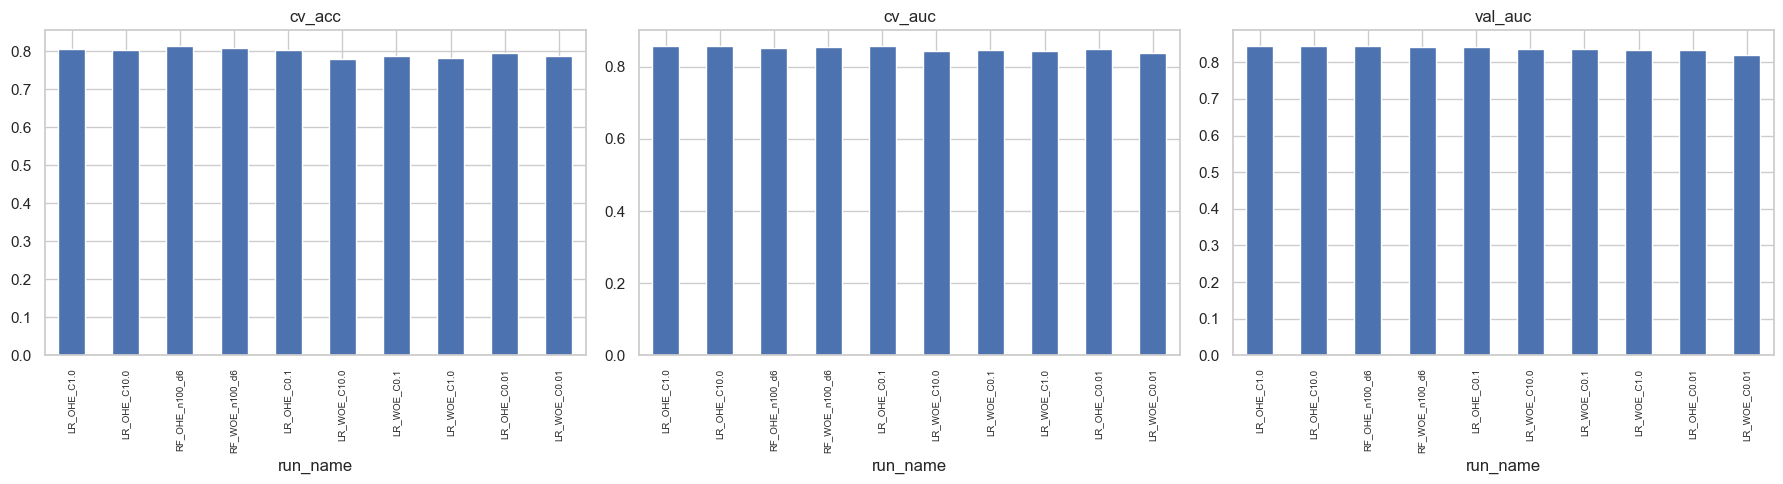

In [47]:
results_df = pd.DataFrame(results).sort_values('val_auc', ascending=False)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['cv_acc', 'cv_auc', 'val_auc']):
    results_df.head(20).plot(x='run_name', y=metric, kind='bar', ax=ax, legend=False)
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

## Register Best Model

Selected by `val_auc`, retrained on train + val combined.

Best run: LR_OHE_C1.0 | val_auc: 0.8452044469568494


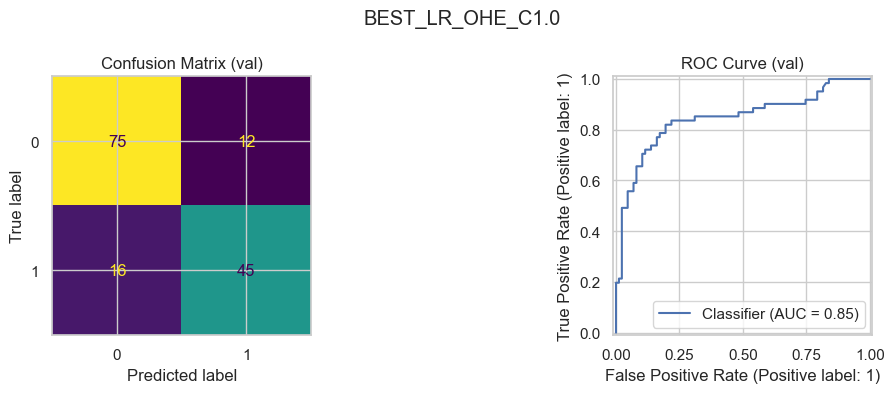

2026/03/28 14:36:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:36:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'titanic-best-model'.
2026/03/28 14:36:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: titanic-best-model, version 1
Created version '1' of model 'titanic-best-model'.


🏃 View run BEST_LR_OHE_C1.0 at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0/runs/4b369829c1f7436da4d1e8074317570c
🧪 View experiment at: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow/#/experiments/0
[BEST_LR_OHE_C1.0] cv_auc=0.8575 val_auc=0.8452  run_id=4b369829c1f7436da4d1e8074317570c
Model registered as 'titanic-best-model' in MLflow Model Registry.


In [48]:
best = results_df.iloc[0]
print('Best run:', best['run_name'], '| val_auc:', best['val_auc'])

best_encoding = 'OHE' if '_OHE_' in best['run_name'] else 'WOE'
X_tr_best  = X_ohe_tr_sel  if best_encoding == 'OHE' else X_woe_tr_sel
X_val_best = X_ohe_val_sel if best_encoding == 'OHE' else X_woe_val_sel

model_map = {
    'LR': lambda: Pipeline([('scaler', StandardScaler()),
                             ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))]),
    'RF': lambda: RandomForestClassifier(n_estimators=100, random_state=42),
}

model_key  = best['run_name'].split('_')[0]
best_model = model_map.get(model_key, model_map['RF'])()

X_full = pd.concat([X_tr_best, X_val_best], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train,   y_val],       axis=0).reset_index(drop=True)
best_model.fit(X_full.values.astype(float), y_full)

log_run(
    f'BEST_{best["run_name"]}',
    best_model,
    X_tr_best, y_train,
    X_val_best, y_val,
    best_encoding,
    register=True
)
print("Model registered as 'titanic-best-model' in MLflow Model Registry.")

In [49]:
artifacts = {
    'best_run_id':   best['run_id'],
    'best_encoding': best_encoding,
    'selected_ohe':  selected_ohe,
    'selected_woe':  selected_woe,
    'woe_encoder':   woe_encoder,
    'numeric_cols':  NUMERIC_COLS,
    'cat_cols':      CAT_COLS,
    'woe_cols':      WOE_COLS,
    'ohe_source_cols': OHE_SOURCE_COLS,
}

with open('preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Artifacts saved. Best run_id:", best['run_id'])

Artifacts saved. Best run_id: d3f7996149fc4da9a17094c6ba0e6bcb
